In [162]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

n = 8                                                   
N = 2**n                                                
n_reduce = 4                                            
N_reduce = 2**n_reduce                                  
t = 5                                                   
dt = 0.01                                               
steps = int(t/dt) + 1                                   
x_max = 10                                              
#x = np.linspace(-x_max, x_max, N, endpoint=False)     
x = np.linspace(-x_max, x_max, N)
dx = x[1] - x[0]                                        
freq = np.fft.fftfreq(N, dx)                            
k = 2 * np.pi * freq                                    
L_half = np.exp(-1j * k**2 * dt/4)                     

In [ ]:

def initial_state_soliton(x, beta=0.5, xc=0.0, v=2.0):
    profile = 1.0 / np.cosh(beta * (x - xc))


    A = 1.0 / np.linalg.norm(profile)


    psi = A * profile * np.exp(1j *0.5 * v * (x - xc))

   
    g = - beta**2 / A**2

    return psi, g, A

In [ ]:

def ssfm(psi, g, dt, L_half):
    psi = np.fft.ifft(np.fft.fft(psi) * L_half)         
    psi = psi*np.exp(-g*1j * np.abs(psi)**2 * dt)       
    psi = np.fft.ifft(np.fft.fft(psi) * L_half)         

    return psi

In [ ]:

def filtering(modes, N, N_reduce):

    half = N_reduce // 2
    filtered_modes = np.zeros(N , dtype=complex)
    filtered_modes[:half] = modes[:half]         
    filtered_modes[-half:] = modes[-half:]        

    return filtered_modes

In [ ]:

def filtered_ssfm(psi, g, dt, L_half, N, N_reduce):
    psi = np.fft.fft(psi) * L_half                      
    modes = filtering(psi, N, N_reduce)
    psi = np.fft.ifft(modes)             

    psi *= np.exp(-g* 1j * np.abs(psi)**2 * dt)        

    psi = np.fft.fft(psi) * L_half                      
    modes = filtering(psi, N, N_reduce)
    psi = np.fft.ifft(modes)
    return psi

In [ ]:

def filtered_qssfm(psi, g, dt, L_half, N, N_reduce):
    psi = np.fft.fft(psi) * L_half                                 
    modes = filtering(psi, N, N_reduce)
    psi = np.fft.ifft(psi)

    nonlinear_term = np.fft.ifft(modes)
    psi *= np.exp(-g* 1j * np.abs(nonlinear_term)**2 * dt)          

    psi = np.fft.fft(psi) * L_half                                  
    modes = filtering(psi, N, N_reduce)
    psi = np.fft.ifft(psi)
    return psi

In [ ]:

def filtered_qssfm_with_norm(psi, g, dt, L_half, N, N_reduce):
    psi = np.fft.fft(psi) * L_half                                  
    modes = filtering(psi, N, N_reduce)       
    psi = np.fft.ifft(psi)

    nonlinear_term = np.fft.ifft(modes)
    norm_factor = 1/np.linalg.norm(nonlinear_term)  
    nonlinear_term = norm_factor *nonlinear_term
    psi *= np.exp(-g* 1j * np.abs(nonlinear_term)**2 * dt)          

    psi = np.fft.fft(psi) * L_half                                
    modes = filtering(psi, N, N_reduce)
    psi = np.fft.ifft(psi)
    return psi

In [ ]:

def percent_k(psi_ssfm, psi_qssfm, N, N_reduce):
    a = np.fft.fft(psi_ssfm)
    b = np.fft.fft(psi_qssfm) 
    b = filtering(b, N, N_reduce)
    eta = np.sum(np.abs(b)**2) / np.sum(np.abs(a)**2)
    
    return eta

In [ ]:

def madelung_momentum(psi, rho_cut=1e-12):
   
    psi= psi/np.sqrt(dx)
    rho = np.abs(psi)**2


    S = np.unwrap(np.angle(psi))

   
    u = np.gradient(S, dx, edge_order=2)

    u = np.where(rho > rho_cut, u, 0.0)

   
    P = np.sum(rho * u) * dx

    return P

In [ ]:

def madelung_energy(psi, g, rho_floor=1e-14, rho_cut=1e-12):

    psi= psi/np.sqrt(dx)
    rho = np.abs(psi)**2
    rho_safe = np.maximum(rho, rho_floor)


    S = np.unwrap(np.angle(psi))
    u = np.gradient(S, dx, edge_order=2)
    u = np.where(rho > rho_cut, u, 0.0)


    rho_x = np.gradient(rho, dx, edge_order=2)


    E_kin = np.sum(0.5 * rho * u**2) * dx
    E_q   = np.sum((rho_x**2) / (8.0 * rho_safe)) * dx
    E_nl  = np.sum(0.5 * g * rho**2) * dx

    E = E_kin + E_q + E_nl

    return E, 
#E_kin, E_q, E_nl

In [ ]:

def error(psi, psi_exact):
    rho_exact = np.abs(psi_exact)**2
    rho1 = np.abs(psi)**2
    error = np.sqrt(np.sum((rho1 - rho_exact)**2) / np.sum(rho_exact**2))
    return error

In [ ]:

if __name__ == "__main__":



    psi0, g, A = initial_state_soliton(x)
    psi1 = np.copy(psi0)
    psi2 = np.copy(psi0)
    psi3 = np.copy(psi0)
    psi_exact = np.copy(psi0)
    psi0density_history = [np.abs(psi0)**2/A**2]                    
    #psi1density_history = [np.abs(psi1)**2/A**2]                   
    psi2density_history = [np.abs(psi2)**2/A**2]                    
    psi3density_history = [np.abs(psi3)**2/A**2]                    
    psi_exactdensity_history = [np.abs(psi_exact)**2/A**2]          
    times = [0]                                                    
    error_history0 = [error(psi0/A, psi_exact/A)]                                                                                
    #error_history1 = [error(psi1/A, psi_exact/A)]                                                                                 
    error_history2 = [error(psi2/A, psi_exact/A)]                                                                                
    error_history3 = [error(psi3/A, psi_exact/A)]                                                                                
    energy0 = [madelung_energy(psi0,g)]
    energy2 = [madelung_energy(psi2,g)]
    energy3 = [madelung_energy(psi3,g)]
    momentum0 =[madelung_momentum(psi0)]
    momentum2 =[madelung_momentum(psi2)]
    momentum3 =[madelung_momentum(psi3)]


    for i in range(steps):
        psi_exact = ssfm(psi_exact, g, dt, L_half)                                                   
        psi0 = ssfm(psi0, g, dt, L_half)
        #psi1 = filtered_ssfm(psi1, g, dt, L_half, N, N_reduce)
        psi2 = filtered_qssfm(psi2, g, dt, L_half, N, N_reduce)
        psi3 = filtered_qssfm_with_norm(psi3, g, dt, L_half, N, N_reduce)


        times.append((i+1)*dt)                            
        psi0density_history.append(np.abs(psi0)**2/A**2)   
        #psi1density_history.append(np.abs(psi1)**2/A**2)   
        psi2density_history.append(np.abs(psi2)**2/A**2)   
        psi3density_history.append(np.abs(psi3)**2/A**2)   
        psi_exactdensity_history.append(np.abs(psi_exact)**2/A**2)                                           
        error_history0.append(error(psi0, psi_exact))                                                   
        #error_history1.append(error(psi1, psi_exact))                                                   
        error_history2.append(error(psi2, psi_exact))                                                   
        error_history3.append(error(psi3, psi_exact))                                                   
        energy0.append(madelung_energy(psi0,g))
        energy2.append(madelung_energy(psi2,g))
        energy3.append(madelung_energy(psi3,g))
        momentum0.append(madelung_momentum(psi0))
        momentum2.append(madelung_momentum(psi2))
        momentum3.append(madelung_momentum(psi3))

In [176]:
np.savez(f"1d-differmethod-effect.npz",    
        times=times,
        psi_ssfm=psi0density_history,
        #psi_filtered_ssfm=psi1density_history,
        psi_filtered_qssfm=psi2density_history,
        psi_filtered_qssfm_with_norm=psi3density_history,
        rel_l2_err_ssfm=error_history0,
        #rel_l2_err_filtered_ssfm=error_history1,
        rel_l2_err_filtered_qssfm=error_history2,
        rel_l2_err_filtered_qssfm_with_norm=error_history3,
        energy0 = energy0,
        energy2 = energy2,
        energy3 = energy3,
        momentum0 = momentum0,
        momentum2 = momentum2,
        momentum3 = momentum3
        ) 

<>:16: SyntaxWarning: invalid escape sequence '\p'
<>:16: SyntaxWarning: invalid escape sequence '\p'
C:\Users\16237\AppData\Local\Temp\ipykernel_6420\2932620897.py:16: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel(r"$|\psi|^2$")


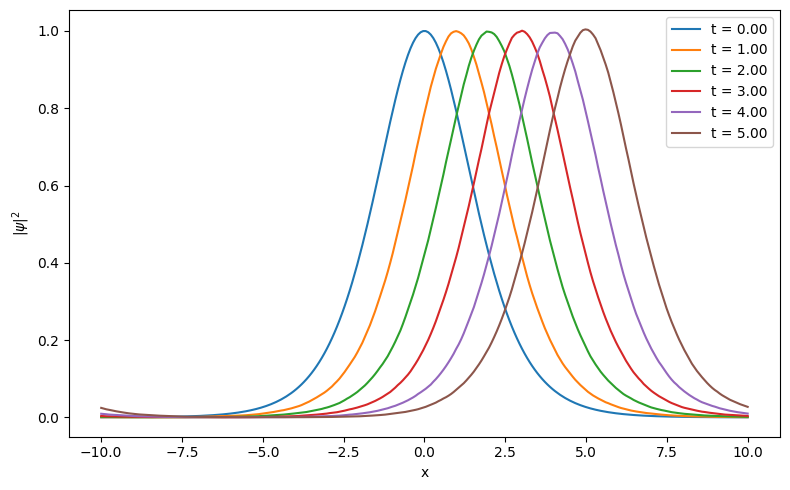

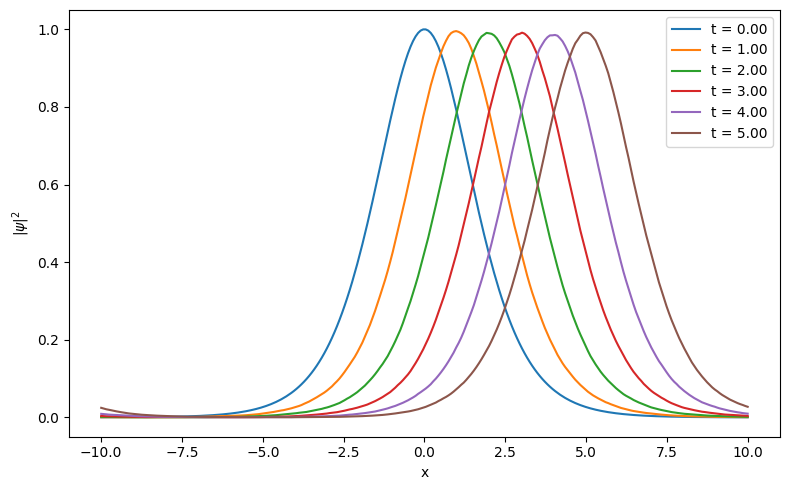

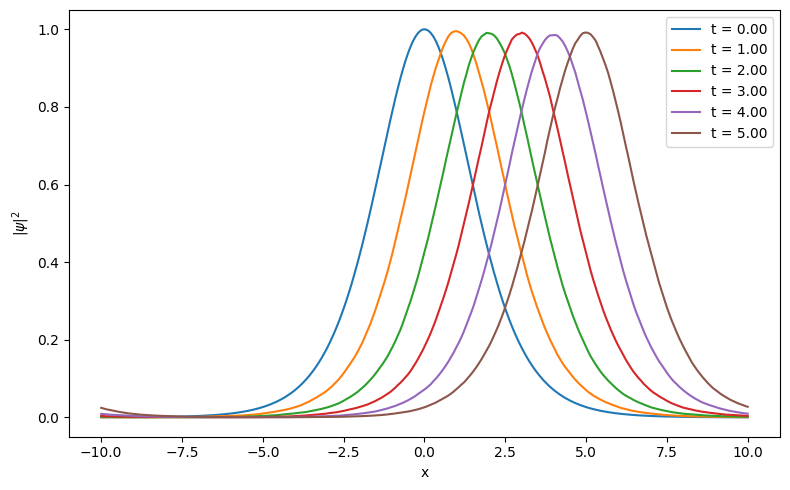

In [177]:
plt.figure(figsize=(8, 5))
for step in range(len(times)):
    if step % 100 == 0:
        plt.plot(x, psi0density_history[step], label=f"t = {times[step]:.2f}")
plt.xlabel("x")
plt.ylabel(r"$|\psi|^2$")
plt.legend()
plt.tight_layout()
plt.show()
'''
plt.figure(figsize=(8, 5))
for step in range(len(times)):
    if step % 100 == 0:
        plt.plot(x, psi1density_history[step], label=f"t = {times[step]:.2f}")
plt.xlabel("x")
plt.ylabel(r"$|\psi|^2$")
plt.legend()
plt.tight_layout()
plt.show()
'''
plt.figure(figsize=(8, 5))
for step in range(len(times)):
    if step % 100 == 0:
        plt.plot(x, psi2density_history[step], label=f"t = {times[step]:.2f}")
plt.xlabel("x")
plt.ylabel(r"$|\psi|^2$")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for step in range(len(times)):
    if step % 100 == 0:
        plt.plot(x, psi3density_history[step], label=f"t = {times[step]:.2f}")
plt.xlabel("x")
plt.ylabel(r"$|\psi|^2$")
plt.legend()
plt.tight_layout()
plt.show()

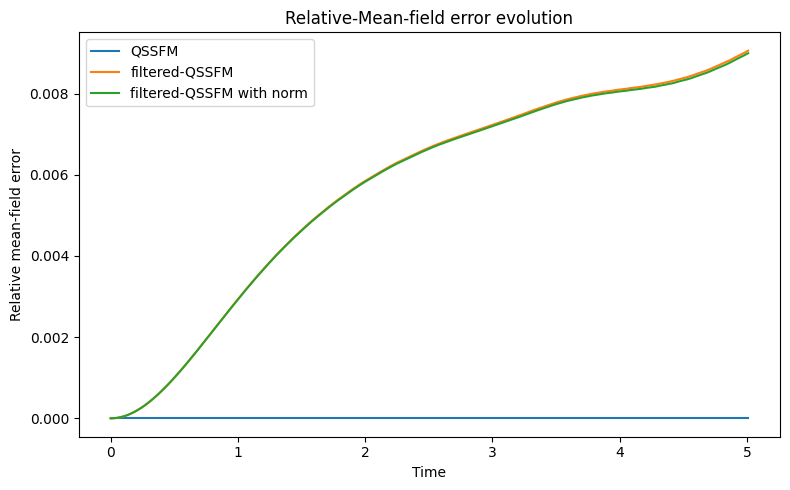

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(times, error_history0, label='QSSFM')
#plt.plot(times, error_history1, label='filtered-SSFM')
plt.plot(times, error_history2, label='filtered-QSSFM')
plt.plot(times, error_history3, label='filtered-QSSFM with norm')

plt.xlabel('Time')
plt.ylabel('Relative mean-field error')

plt.legend()
plt.title('Relative-Mean-field error evolution')
plt.tight_layout()

plt.show()

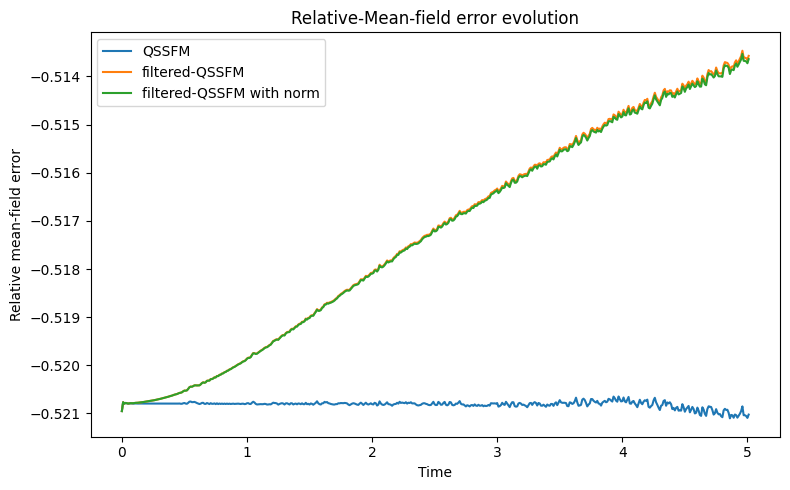

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(times, energy0, label='QSSFM')
#plt.plot(times, error_history1, label='filtered-SSFM')
plt.plot(times, energy2, label='filtered-QSSFM')
plt.plot(times, energy3, label='filtered-QSSFM with norm')

plt.xlabel('Time')
plt.ylabel('Relative mean-field error')

plt.legend()
plt.title('Relative-Mean-field error evolution')
plt.tight_layout()

plt.show()

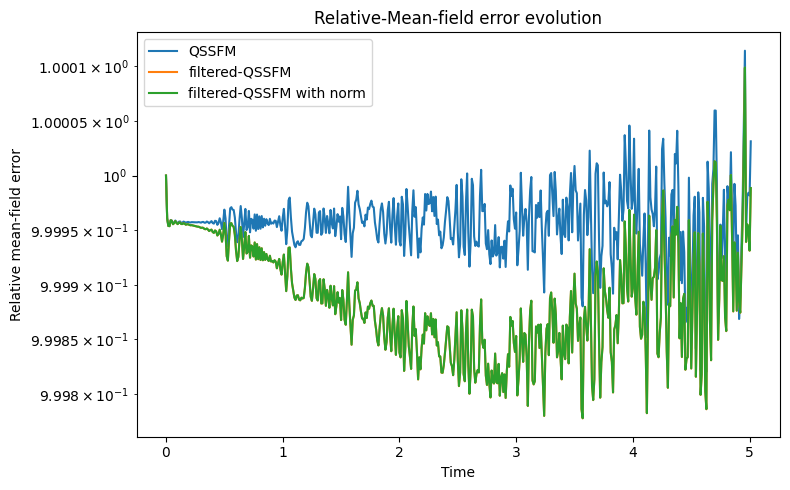

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(times, momentum0, label='QSSFM')
#plt.plot(times, error_history1, label='filtered-SSFM')
plt.plot(times, momentum2, label='filtered-QSSFM')
plt.plot(times, momentum3, label='filtered-QSSFM with norm')

plt.xlabel('Time')
plt.ylabel('Relative mean-field error')

plt.legend()
plt.title('Relative-Mean-field error evolution')
plt.tight_layout()

plt.show()